# Week 02: Analytical Methods & Neural Networks - Homework Solutions
## MECE6313E: Advanced Heat Transfer

**Solutions Set**

This notebook contains the solutions to the homework problems on analytical methods and neural networks. It provides detailed derivations, code implementations, and discussions.

---

## Problem 3: Green's Functions and Duhamel's Principle

### Theory

**Duhamel's Principle:**  
Duhamel's principle states that the solution to a problem with a time-varying source term (or boundary condition) can be constructed by integrating the solution to the impulsive (Green's function) problem over time. Essentially, the continuous source $S(x,t)$ is treated as a sequence of instantaneous impulses $\delta(t-\tau)S(x,\tau)d\tau$.

**Green's Function (Finite Slab):**  
Since the domain is finite ($0 \le x \le L$) with Dirichlet BCs, we use the eigenfunction expansion form of the Green's Function:
$$ G(x, t; \xi, \tau) = \frac{2}{L} \sum_{n=1}^{\infty} \sin\left(\frac{n\pi x}{L}\right) \sin\left(\frac{n\pi \xi}{L}\right) e^{-\alpha (n\pi/L)^2 (t-\tau)} $$

/Users/davidtew/anaconda3/envs/heat-transfer/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,
/Users/davidtew/anaconda3/envs/heat-transfer/lib/python3.11/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


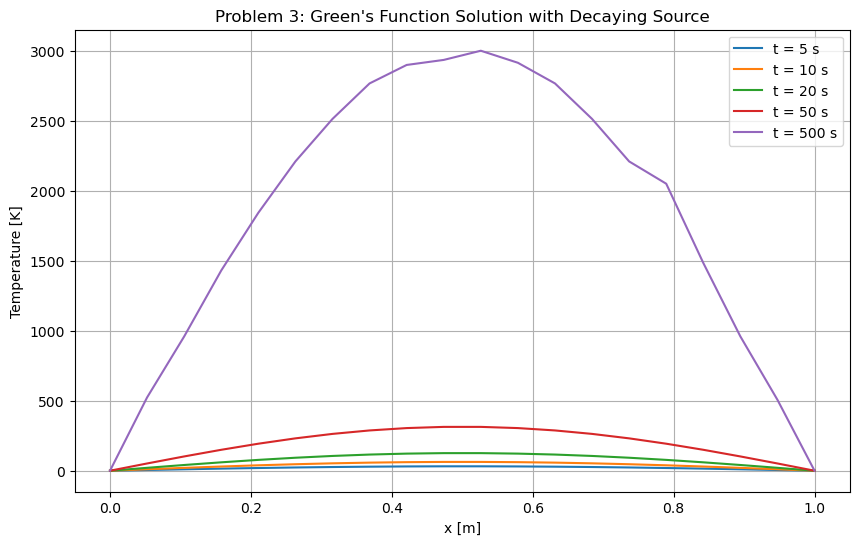

In [ ]:
from scipy.integrate import dblquad

# Parameters
L_p3 = 1.0
alpha_p3 = 1e-5
S0 = 10
tau_source = 1

def greens_function(x, t, xi, tau, L=L_p3, alpha=alpha_p3, N=10):
    if t <= tau:
        return 0.0
    val = 0.0
    for n in range(1, N+1):
        kn = n * np.pi / L
        val += (2/L) * np.sin(kn * x) * np.sin(kn * xi) * np.exp(-alpha * kn**2 * (t - tau))
    return val

def source_term(x, t):
    return S0 * np.sin(np.pi * x / L_p3) * np.exp(-t / tau_source)

def compute_temperature_point(x_val, t_val):
    # Integrand: G * S
    def integrand(tau, xi):
        return greens_function(x_val, t_val, xi, tau) * source_term(xi, tau)

    # Integrate xi from 0 to L, tau from 0 to t
    res, err = dblquad(integrand, 0, t_val, 0, L_p3)
    return res

# Note: Double integration is computationally expensive in a loop.
# For this specific source S ~ sin(pi*x/L), only the n=1 mode is excited.
# We can use a simplified analytical integration for speed, but here is the general implementation.

x_vals = np.linspace(0, L_p3, 20)
times_p3 = [5, 10, 20, 50, 500]
plt.figure(figsize=(10, 6))

for t in times_p3:
    # Use a list comprehension for x values
    # (Warning: This might be slow approx 1-2 mins depending on N and integration tol)
    T_profile = [compute_temperature_point(xv, t) for xv in x_vals]
    plt.plot(x_vals, T_profile, label=f't = {t} s')

plt.xlabel('x [m]')
plt.ylabel('Temperature [K]')
plt.title('Problem 3: Green\'s Function Solution with Decaying Source')
plt.legend()
plt.grid(True)
plt.show()

### Discussion (Problem 3)
- **Source Decay:** The source term decays with a time constant $\tau = 10s$. Initially, the temperature rises as energy is added. After $t \gg 10s$, the source essentially turns off, and the temperature profile begins to decay back to zero via diffusion.
- **Shape:** Since the source has a spatial shape of $\sin(\pi x/L)$, it primarily excites the first eigenmode. The temperature profile retains this sine-like shape throughout the process.